# Data5441 - Networks and High-dimensional Inference 
Semester 2, 2026


# Tutorial Week 6


The goal of this tutorial is to learn about:

- the Metropolis Markov chain Monte Carlo method (MCMC) for sampling random numbers from different probability density functions $p(x)$. 
- exponential random graph models (ERGMs), a flexible family of random-graph models that allows different constraints to be imposed.

The key connection between these topics is that Metropolis MCMC allows us to sample graphs for specified ERGM parameters. These samples can then be used in a separate simulation-based procedure to fit the parameters.


In [42]:
import matplotlib.pyplot as plt
import numpy as np
import networkx as nx
import pandas as pd

SEED = 5441
rng = np.random.default_rng(SEED)

# 1. Metropolis method

The Metropolis algorithm is a Monte Carlo method used to sample from a probability distribution when direct sampling is difficult. It is widely used in statistical physics, Bayesian inference, and network science, especially for sampling from posterior distributions or exploring high-dimensional spaces. 

**Algorithm**

The Metropolis algorithm constructs a Markov chain whose stationary distribution is the desired distribution. Let $p(x)$ be the target probability distribution, $\Pi(x\mapsto x')$ the proposal probability, $A(x\mapsto x')$ the acceptance probability, and $W(x\mapsto x')$ the complete one-step transition probability. For $x'\neq x$,

$$W(x\mapsto x')=\Pi(x\mapsto x')A(x\mapsto x').$$

For a discrete state space, rejected proposals give the diagonal term

$$W(x\mapsto x)=1-\sum_{y\neq x}\Pi(x\mapsto y)A(x\mapsto y).$$

The algorithm below first assumes a symmetric proposal, $\Pi(x\mapsto x')=\Pi(x'\mapsto x)$, and proceeds as follows:

- Initialize the chain at some state $x_0$.
- For each iteration $t = 0, 1, \dots$:
1. Propose a new state $x'$ from $\Pi(x_t\mapsto x')$.
2. Compute the Hastings ratio $R=p(x')/p(x_t)$.
3. Accept the proposed state with probability $A(x_t\mapsto x')=\min(1,R)$:
 $$
        x_{t+1} = 
        \begin{cases}
        x' & \text{with probability } A(x_t\mapsto x') \\
        x_t & \text{otherwise}
        \end{cases}
   $$
    
**Properties:**

- With a symmetric proposal, the acceptance rule gives a transition probability satisfying detailed balance: $p(x)W(x\mapsto x')=p(x')W(x'\mapsto x)$.
- If the chain is also irreducible and aperiodic, it converges to $p(x)$ from any allowed initial state.
- For a nonsymmetric proposal, use the Hastings acceptance probability

$$A(x\mapsto x')=\min\left[1,\frac{p(x')\Pi(x'\mapsto x)}{p(x)\Pi(x\mapsto x')}\right].$$
- It is particularly useful when $p(x)$ is known up to a normalization constant.


## 1.1. Example of the Metropolis algorithm: sampling $x$ from $p(x)=2x$ on $[0,1]$

To illustrate the MCMC method, we use only uniform random-number generation through `rng.uniform(0, 1)`.


## 1.2. Proposal probability $\Pi(x\mapsto x')$

$x'$ is sampled uniformly from $[x-0.01,x+0.01]$. We use periodic boundary conditions, for example $x'=1.01\mapsto0.01$.

This deliberately small proposal step mixes slowly and illustrates correlations between successive MCMC samples.


In [43]:
def Pi_local(x, rng, step=0.01):
    """Symmetric local proposal on [0, 1] with periodic boundaries."""
    # return (x + rng.uniform(-step, step)) % 1.0
    return rng.uniform(0, 1)

## 1.3. Acceptance rule

As derived in class, the acceptance probability is $A(x\mapsto x')=\min[1,p(x')/p(x)]$ because $\Pi(x\mapsto x')=\Pi(x'\mapsto x)$. Here $p(x)=2x$, so the ratio inside the minimum is $x'/x$.


In [44]:
def A_linear(x, xp):
    """Return the acceptance probability A(x mapsto xp)."""
    if x == 0:
        return float(xp > 0)
    return min(1.0, xp / x)

## 1.4. Starting from $x=0.5$, sample points for $t=1, \ldots, S$


In [45]:
x = 0.5
rejections_1000 = 0
samples_1000 = []
for _ in range(1_000):
    xp = Pi_local(x, rng)
    if rng.random() < A_linear(x, xp):
        x = xp
    else:
        rejections_1000 += 1
    samples_1000.append(x)

In [46]:
x = 0.5
rejections_million = 0
samples_million = []
for _ in range(1_000_000):
    xp = Pi_local(x, rng)
    if rng.random() < A_linear(x, xp):
        x = xp
    else:
        rejections_million += 1
    samples_million.append(x)

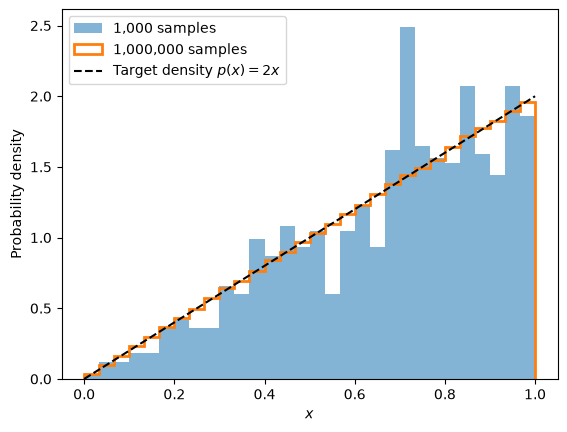

In [47]:
bins = np.linspace(0, 1, 31)
plt.hist(samples_1000, bins=bins, density=True, alpha=0.55, label="1,000 samples")
plt.hist(samples_million, bins=bins, density=True, histtype="step", linewidth=2, label="1,000,000 samples")
plt.plot([0, 1], [0, 2], "--", color="black", label="Target density $p(x)=2x$")
plt.xlabel("$x$")
plt.ylabel("Probability density")
plt.legend()
plt.show()

## Exercise 1.1. Interpret the code above

(a) Does the approach above work?

For sufficiently many iterations, the empirical distribution of the samples approaches $p(x)$, but the samples are correlated because the proposal moves only a small distance at each step.

(b) Why are the results for $S=1,000$ and $S=1,000,000$ different? Would increasing to $S=1,000,000,000$ make any further difference?

For $S=1,000$, the proposal step is $|x-x'| \leq 0.01$, so there may not be enough time for every state to be explored. $S=1,000,000$ has sufficiently more time to move around the state space, forget the initial state, revisit regions many times, and average out random fluctuations.
Changing to $S=1,000,000,000$ would reduce Monte Carlo noise, but it would just lead to a smoother version of the same limiting distribution.

(c) Why does the result for $S=1,000$ remain concentrated near the initial part of the trajectory? 

(d) How would you modify the code above to make the method more efficient?

Sample $x' \sim U[0,1]$



## Exercise 1.2. Test and modify the code: the role of the proposal $\Pi$



Let $\bar{x}_S=S^{-1}\sum_{t=1}^S x_t$ be the sample average computed using the Metropolis algorithm above.

(a) What is the limiting value of $\bar{x}_S$ as $S\to\infty$?

(b) Compute how $\bar{x}_S$ depends on $S$, up to $S=3,000$.

(c) Modify the proposal probability $\Pi(x\mapsto x')$ so that $x'$ is uniform on $[0,1]$. Compute how $\bar{x}_S$ changes with $S$ in this case.

(d) Which version of the proposal is better and why?


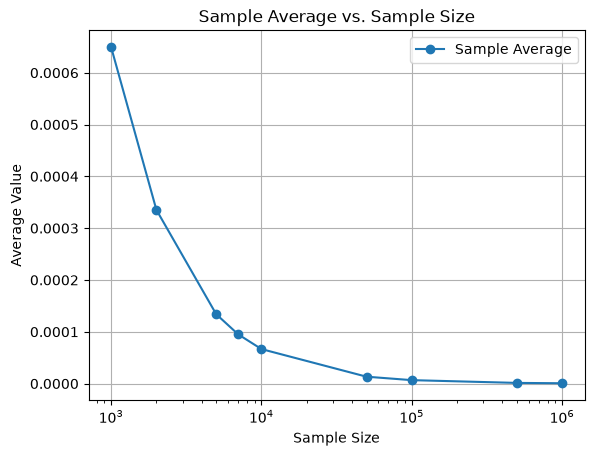

In [48]:
def run_MH(init, sample_size=1_000):
    x = init
    rejections = 0
    samples = []
    for _ in range(sample_size):
        xp = Pi_local(x, rng)
        if rng.random() < A_linear(x, xp):
            x = xp
        else:
            rejections += 1
        samples.append(x)
    return samples, rejections

def calculate_sample_average(samples):
    return np.mean(samples) / len(samples)


ss = [1_000, 2_000, 5_000, 7_000, 10_000, 50_000, 100_000, 500_000, 1_000_000]
sample_averages = []

for sample_size in ss:
    samples, rejections = run_MH(0.5, sample_size)
    sample_averages.append(calculate_sample_average(samples))

plt.plot(ss, sample_averages, marker='o', label='Sample Average')
plt.xlabel('Sample Size')
plt.ylabel('Average Value')
plt.title('Sample Average vs. Sample Size')
plt.legend()
plt.xscale('log')
plt.grid(True)
plt.show()

## Exercise 1.3. Modify the code to sample from other distributions $p(x)$



(a) Can we sample random numbers from the distribution $p(x) = 3x$? 
- How? Modify the code above to achieve this.
- What is the expected value $\mathbb{E}[x]$ in this case?

(b) Can we sample random numbers from the distribution $p(x) = \alpha x^2$ for $x\in[0,1]$? 
- How? Modify the code above to achieve this.
- What value of $\alpha$ should we use? How does $\alpha$ affect the code? Why?
- What is the expected value $\mathbb{E}[x]$ in this case?



In [49]:
def Pi_local(x, rng, step=0.01):
    """Symmetric local proposal on [0, 1] with periodic boundaries."""
    # return (x + rng.uniform(-step, step)) % 1.0
    return rng.uniform(0, 1)

def A_quadratic(x, xp):
    if x == 0:
        return float(xp > 0)
    return min(1.0, (xp / x)**2)

In [50]:
x=0.5
rejections_million = 0
samples_million = []
for _ in range(1_000_000):
    xp = Pi_local(x, rng)
    if rng.random() < A_quadratic(x, xp):
        x = xp
    else:
        rejections_million += 1
    samples_million.append(x)

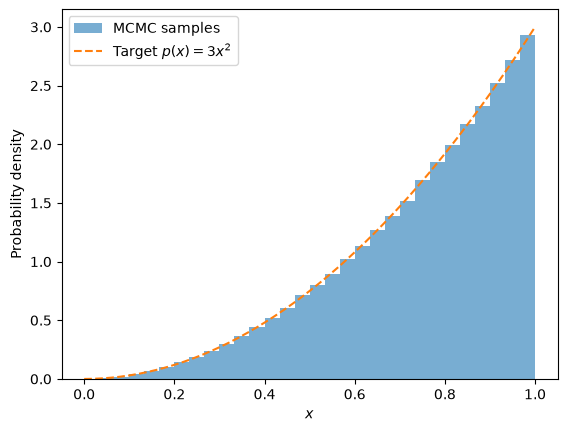

In [51]:
bins = np.linspace(0, 1, 31)
plt.hist(samples_million, bins=bins, density=True, linewidth=2, label="MCMC samples", alpha=0.6)

xs = np.linspace(0, 1, 200)
plt.plot(xs, 3 * xs**2, "--", label=r"Target $p(x)=3x^2$")

plt.xlabel("$x$")
plt.ylabel("Probability density")
plt.legend()
plt.show()

# 2. Metropolis method in networks

Here you are invited to use the Metropolis method to sample from the set $\Omega$ of labeled, simple $k$-regular graphs on $N$ nodes, assigning different probabilities $p(g)$ to graphs $g\in\Omega$. All cases below start from a $k$-regular graph generated with

```
nx.random_regular_graph(k, N)
```

and sample proposals $g'$ from $\Pi(g\mapsto g')$ using degree-preserving double-edge swaps

```
nx.double_edge_swap()
```
The proposed graph is accepted with probability $A(g\mapsto g')$. Together, $\Pi$ and $A$ define the complete one-step transition probability $W(g\mapsto g')$.


## Exercise 2.1. Metropolis method in networks


Consider random-graph models with $N=50$ nodes, each with degree $k=4$, and probabilities $p(g)=p(C(g))$ specified below, where $C(g)$ is the network transitivity. For each model, plot $C(g(t))$ as a function of Markov time $t$ and numerically estimate the ensemble-average clustering

$$ C_{RG} \equiv \sum_{g\in\Omega} p(g) C(g). $$


In [52]:
N = 50
k = 4

def random_regular_initial(seed=None):
    return nx.random_regular_graph(k, N, seed=seed)


def Pi(G, rng):
    """Propose one degree-preserving double-edge swap."""
    H = G.copy()
    nx.double_edge_swap(H, nswap=1, max_tries=100, seed=int(rng.integers(0, 2**32 - 1)))
    return H


def sample_graph(weight, steps=50_000, burn_in=10_000, thin=100, seed=None):
    rng = np.random.default_rng(seed)

    G = random_regular_initial(seed=int(rng.integers(0, 2**32 - 1)))

    C = nx.transitivity(G)
    w = weight(C)

    C_history = np.empty(steps + 1)
    C_history[0] = C

    samples = []
    accepted = 0

    for t in range(steps):

        H = Pi(G, rng)

        C_new = nx.transitivity(H)
        w_new = weight(C_new)

        if w == 0:
            if w_new > 0:
                alpha = 1.0
            else:
                alpha = 1.0
        else:
            alpha = min(1.0, w_new / w)

        if rng.random() < alpha:
            G = H
            C = C_new
            w = w_new
            accepted += 1

        C_history[t + 1] = C

        if t >= burn_in and (t - burn_in) % thin == 0:
            samples.append(C)

    return (np.asarray(samples), C_history, accepted / steps)

(a) Uniform probability: $p(g)=$ constant.

Estimated C_RG = 0.04675
Acceptance rate = 1.000
Number of equilibrium samples = 400


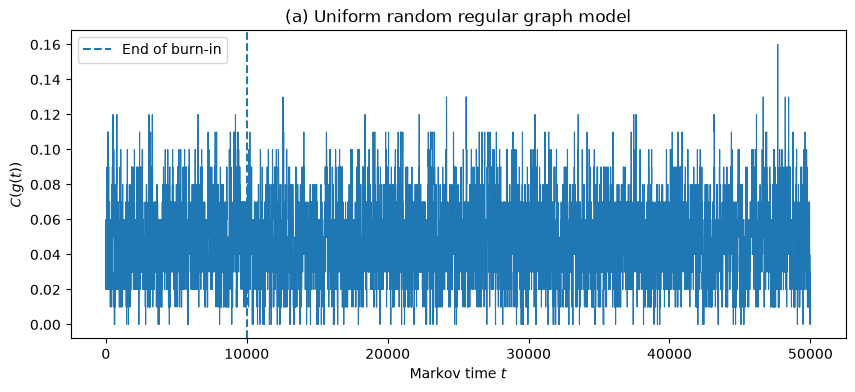

In [53]:
def weight_uniform(C):
    return 1.0

RUN_UNIFORM = True
if RUN_UNIFORM:
    uniform_samples, uniform_history, uniform_acceptance = sample_graph(weight_uniform, seed=SEED)
else:
    df_uniform = pd.read_csv("OUTPUTS/uniform.csv")
    uniform_samples = df_uniform["samples"].to_numpy()
    uniform_history = None
    uniform_acceptance = None

C_RG_uniform = np.mean(uniform_samples)

if RUN_UNIFORM:
    print(f"Estimated C_RG = {C_RG_uniform:.5f}")
    print(f"Acceptance rate = {uniform_acceptance:.3f}")
    print(f"Number of equilibrium samples = {len(uniform_samples)}")

    plt.figure(figsize=(10, 4))
    plt.plot(uniform_history, linewidth=0.8)
    plt.axvline(10_000, linestyle="--", label="End of burn-in")
    plt.xlabel("Markov time $t$")
    plt.ylabel("$C(g(t))$")
    plt.title("(a) Uniform random regular graph model")
    plt.legend()
    plt.show()
    
    pd.DataFrame({"samples": uniform_samples}).to_csv("OUTPUTS/uniform.csv", index=False)
else:
    print(f"Estimated C_RG = {C_RG_uniform:.5f}")
    print(f"Number of equilibrium samples = {len(uniform_samples)}")

(b) Linearly proportional to $C$: $$p(g) = \gamma C(g),$$ where $\gamma$ is a normalization constant such that $\sum_{g \in \Omega} p(g)=1$. 

Estimated C_RG = 0.05553
Acceptance rate = 0.952
Number of equilibrium samples = 400


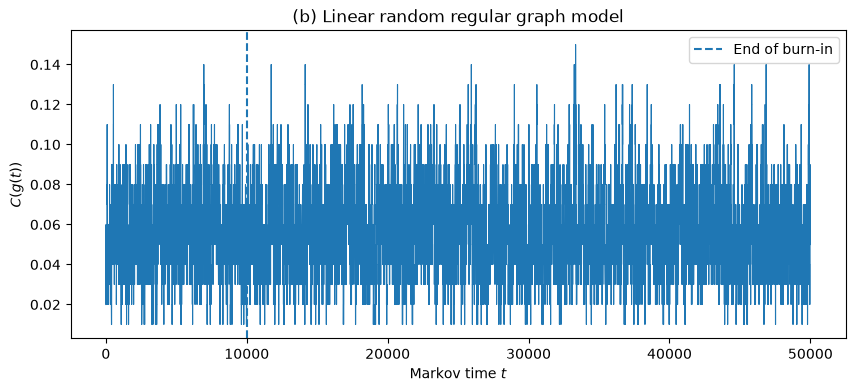

In [54]:
def weight_linear(C):
    return C

RUN_LINEAR = True
if RUN_LINEAR:
    linear_samples, linear_history, linear_acceptance = sample_graph(weight_linear, seed=SEED)
else:
    df_linear = pd.read_csv("OUTPUTS/linear.csv")
    linear_samples = df_linear["samples"].to_numpy()
    linear_history = None
    linear_acceptance = None

C_RG_linear = np.mean(linear_samples)

if RUN_LINEAR:
    print(f"Estimated C_RG = {C_RG_linear:.5f}")
    print(f"Acceptance rate = {linear_acceptance:.3f}")
    print(f"Number of equilibrium samples = {len(linear_samples)}")

    plt.figure(figsize=(10, 4))
    plt.plot(linear_history, linewidth=0.8)
    plt.axvline(10_000, linestyle="--", label="End of burn-in")
    plt.xlabel("Markov time $t$")
    plt.ylabel("$C(g(t))$")
    plt.title("(b) Linear random regular graph model")
    plt.legend()
    plt.show()
    
    pd.DataFrame({"samples": linear_samples}).to_csv("OUTPUTS/linear.csv", index=False)
else:
    print(f"Estimated C_RG = {C_RG_linear:.5f}")
    print(f"Number of equilibrium samples = {len(linear_samples)}")

(c) Proportional to the tenth power of $C(g)$: $$p(g) = \alpha C(g)^{10},$$ where $\alpha$ is a normalization constant such that $\sum_{g \in \Omega} p(g)=1$.

Hint: Account for equilibration and correlation between successive graph samples. Use the same sampling lag in all three cases so that their traces can be compared on the same Markov-time scale. The normalization constants $\gamma$ and $\alpha$ cancel from the Hastings ratio.

Estimated C_RG = 0.10648
Acceptance rate = 0.716
Number of equilibrium samples = 400


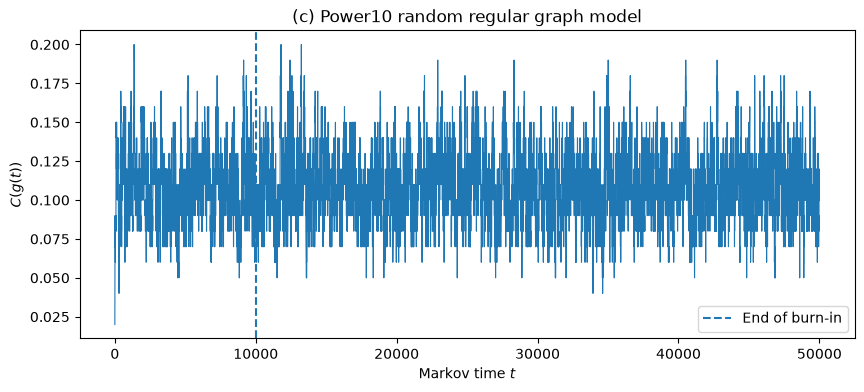

In [55]:
def weight_power10(C):
    return C**10

RUN_POWER10 = True
if RUN_POWER10:
    power10_samples, power10_history, power10_acceptance = sample_graph(weight_power10, seed=SEED)
else:
    df_power10 = pd.read_csv("OUTPUTS/power10.csv")
    power10_samples = df_power10["samples"].to_numpy()
    power10_history = None
    power10_acceptance = None

C_RG_power10 = np.mean(power10_samples)

if RUN_POWER10:
    print(f"Estimated C_RG = {C_RG_power10:.5f}")
    print(f"Acceptance rate = {power10_acceptance:.3f}")
    print(f"Number of equilibrium samples = {len(power10_samples)}")

    plt.figure(figsize=(10, 4))
    plt.plot(power10_history, linewidth=0.8)
    plt.axvline(10_000, linestyle="--", label="End of burn-in")
    plt.xlabel("Markov time $t$")
    plt.ylabel("$C(g(t))$")
    plt.title("(c) Power10 random regular graph model")
    plt.legend()
    plt.show()
    
    pd.DataFrame({"samples": power10_samples}).to_csv("OUTPUTS/power10.csv", index=False)
else:
    print(f"Estimated C_RG = {C_RG_power10:.5f}")
    print(f"Number of equilibrium samples = {len(power10_samples)}")

(d*) Reflect on the effect of the choice of $p(g)$ on $C_{RG}$. Networks with high clustering exist in $\Omega$; in fact, there are graphs $g\in\Omega$ with $C(g)=1$. Can you construct one?

Number of nodes: 50
Number of edges: 100
All degrees equal to 4: True
Transitivity: 1.0


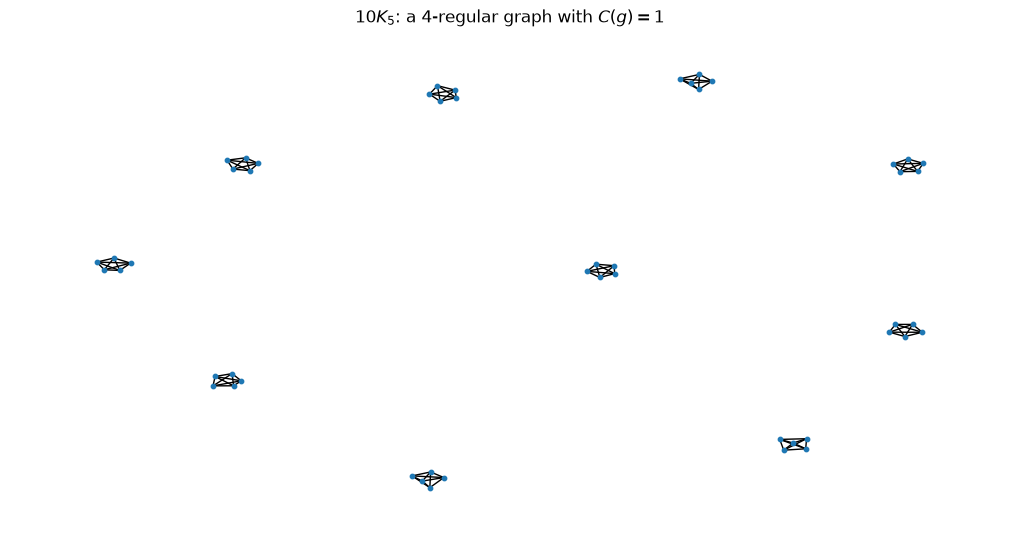

In [65]:
G_max = nx.disjoint_union_all([nx.complete_graph(5) for _ in range(10)])

print("Number of nodes:", G_max.number_of_nodes())
print("Number of edges:", G_max.number_of_edges())
print("All degrees equal to 4:", all(d == 4 for _, d in G_max.degree()))
print("Transitivity:", nx.transitivity(G_max))

plt.figure(figsize=(10,5))

pos = nx.spring_layout(G_max, seed=SEED)
nx.draw(G_max, pos, node_size=10, with_labels=False)
plt.title(r"$10K_5$: a 4-regular graph with $C(g)=1$")
plt.show()

# 3. Exponential random graph models


**Exponential random graph models (ERGMs)** define a probability distribution over a specified sample space of graphs. The probability of a graph depends on network statistics such as its number of edges or triangles.

Formally, the probability of observing a graph $g$ is given by:

$$
p(g) = \frac{1}{Z(\beta)} \exp\left( \sum_{k=1}^K \beta_k s_k(g) \right)
$$

where:
- $s_k(g)$ are network statistics (e.g., number of edges, triangles),
- $\beta_k$ are parameters associated with these statistics,
- $Z(\beta)$ is the normalizing constant (partition function), often intractable to compute directly.

Because $Z(\beta)$ is often difficult to evaluate, sampling from ERGMs and fitting their parameters commonly relies on Metropolis-Hastings MCMC methods. MCMC samples can then be used in a separate simulation-based fitting procedure to estimate ERGM parameters from observed network data.


## Application to the November 17 network

We illustrate an ERGM using a simple network $G$ and the clustering coefficient $C$ as the single statistics $x$ of interest.

As $G$, we consider the reported associations among members of the November 17 Greek terrorist organization. Nodes represent members, and an edge indicates that two members had some association in the past. 

Source: [November 17 network, Netzschleuder](https://networks.skewed.de/net/november17). The original study is C. J. Rhodes and P. Jones, *Inferring missing links in partially observed social networks*, Journal of the Operational Research Society **60**, 1373–1383 (2009).

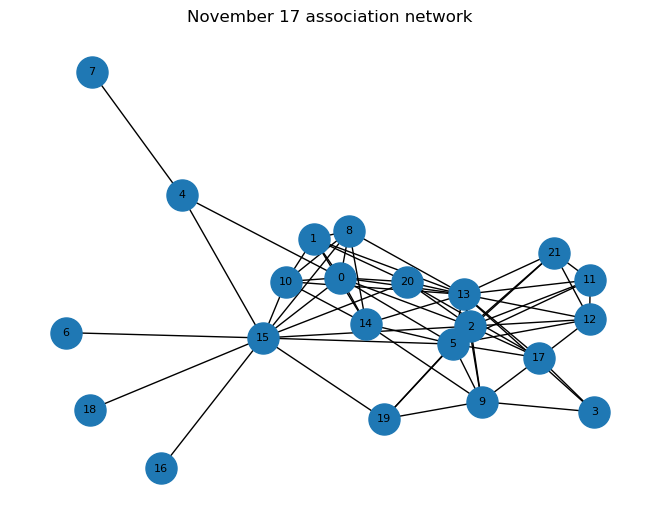

N = 22, L = 66, C(G) = 0.529


In [25]:
G = nx.read_edgelist("data/edges-november17.csv", delimiter=",", nodetype=int)
N_n17 = G.number_of_nodes()
L_n17 = G.number_of_edges()
pos = nx.spring_layout(G, seed=SEED)
nx.draw(G, pos=pos, with_labels=True, node_size=500, font_size=8)
plt.title("November 17 association network")
plt.show()

print(f"N = {N_n17}, L = {L_n17}, C(G) = {nx.transitivity(G):.3f}")

As the network statistic, we use transitivity, $s_1(g)=C(g)$.

In [26]:
nx.transitivity(G)

0.5286624203821656

In order to identify the most important individuals in this criminal network, we compute the betweeness centrality of each node as:

In [27]:
betweenness = nx.betweenness_centrality(G)
top_betweenness = sorted(
    ((value, node) for node, value in betweenness.items()),
    reverse=True,
)
print("Top 10 nodes with largest betweenness centrality:")
for value, node in top_betweenness[:10]:
    print(node, "\t", value)

Top 10 nodes with largest betweenness centrality:
15 	 0.34832199546485265
13 	 0.1748639455782313
0 	 0.120249433106576
5 	 0.11012471655328801
2 	 0.1043310657596372
4 	 0.09523809523809525
20 	 0.026133786848072566
9 	 0.024206349206349207
17 	 0.018015873015873016
10 	 0.014682539682539684


The results above suggest node 15 as being extremely important as a bridge between other individuals in this network. In order to confirm whether this is indeed an important feature of this network, we compare these results with the expectation based on random graph models. In the exercise below, we focus on the observed *maximum* and ask whether it is explained by the degree sequence and clustering (rather than interpreting any particular individual).

## Problem formulation

The question is whether such high betweenness centrality is expected based on:
- The degrees observed in the network (i.e., the number of reported associations of each member).
- The clustering coefficient of the network (i.e., the tendency of reported associations to form triangles).

## Problem formalization

We compare the observed November 17 network $G$ with random graphs that have exactly the same degree sequence. Within this restricted sample space $\Omega(\mathbf z)$, we use the conditional ERGM

$$p_\beta(g)=\frac{1}{Z(\beta)}\exp[\beta C(g)],\qquad g\in\Omega(\mathbf z),$$

and fit $\beta$ so that the ensemble expectation satisfies $C_{RG,\beta}=\mathbb{E}_\beta[C(g)]=C(G)$. Individual sampled graphs fluctuate around this value; they do not all have exactly the same clustering.

## Computation

The problem can be tackled by sampling graphs $g$ using an MCMC method that:
- starts from $g(t=0)=G$ and proposes degree-preserving edge swaps with $\Pi(g\mapsto g')$;
- allows both connected and disconnected proposed graphs;
- applies the full transition $W(g\mapsto g')$, constructed from the proposal $\Pi(g\mapsto g')$ and the Metropolis acceptance $A(g\mapsto g')$, with statistic $C(g)$; and
- fits $\beta$ so that $C_{RG,\beta}=C(G)$.

We can then compare the observed maximum betweenness centrality with its distribution under the fitted model to assess whether degree sequence and clustering explain the observation.

The NetworkX function `nx.double_edge_swap(..., nswap=1)` repeatedly draws edge pairs until a valid swap is found. Conditioning on success introduces a graph-dependent normalization and therefore makes $\Pi(g\mapsto g')$ only approximately symmetric. For the graph families considered in this notebook, the resulting Hastings correction is small, but exact symmetry is easy to recover: make exactly one edge-pair draw and return $g'=g$ when that draw is invalid. The function below implements this single-attempt proposal. Its Boolean output records whether the draw produced a nontrivial swap.


In [28]:
def Pi_single_edge_swap(g, rng):
    """Draw one symmetric degree-preserving edge-swap proposal.

    An invalid draw gives the self-proposal h = g. The Boolean return
    value indicates whether a nontrivial swap was proposed.
    """
    if g.is_directed():
        raise nx.NetworkXError("The proposal requires an undirected graph.")

    edges = list(g.edges())
    if len(edges) < 2:
        raise nx.NetworkXError("The graph must contain at least two edges.")

    def draw_oriented_edge():
        u, v = edges[rng.integers(len(edges))]
        if rng.random() < 0.5:
            u, v = v, u
        return u, v

    u, v = draw_oriented_edge()
    x, y = draw_oriented_edge()
    proposed = g.copy()

    # One failed draw is a self-proposal; do not try another pair.
    if u == x or v == y or g.has_edge(u, x) or g.has_edge(v, y):
        return proposed, False

    proposed.remove_edge(u, v)
    proposed.remove_edge(x, y)
    proposed.add_edge(u, x)
    proposed.add_edge(v, y)
    return proposed, True


## Exercise 3.1. ERGMs for the November 17 network


(a) Apply the transition $W$, using the double-edge-swap proposal $\Pi$, for $t$ steps at $\beta=0$ and plot how $C(g(t))$ depends on $t$. Is the observed clustering explained by the degree sequence alone?

(b) Vary $\beta$ and plot how $C_{RG,\beta}$ depends on $\beta$. Include regions with $C_{RG,\beta}<C(G)$ and $C_{RG,\beta}>C(G)$. To improve equilibration, when changing $\beta\mapsto\beta+\Delta\beta$, use the final graph sampled at $\beta$ as the initial condition at $\beta+\Delta\beta$. Sweep $\beta$ in both directions to check for incomplete equilibration.

(c) From the plot, estimate $\beta=\beta^*$ such that $C_{RG,\beta^*}=C(G)$. Validate the estimate with a separate sample at $\beta^*$.

(d) Is the maximum betweenness centrality observed in the November 17 network explained by its degree sequence and clustering? Compare it with the distribution of the maximum betweenness centrality under the fitted ERGM.

(e) Examine how clustering affects the maximum betweenness centrality. Sample graphs at different $\beta$, and for each $\beta$ compute the average $C$ and the average maximum betweenness centrality. Report standard deviations to describe graph-to-graph fluctuations.


# 4. Hints


- To reduce correlations between graph samples, perform several MCMC steps between recorded observations. The required lag depends on the chain's autocorrelation time.

- To assess whether an observed result is surprising, report both the ensemble mean and the graph-to-graph fluctuations, for example the sample standard deviation.

Plotting with error bars:


In [42]:
help(plt.errorbar)

Help on function errorbar in module matplotlib.pyplot:

errorbar(x: 'float | ArrayLike', y: 'float | ArrayLike', yerr: 'float | ArrayLike | None' = None, xerr: 'float | ArrayLike | None' = None, fmt: 'str' = '', *, ecolor: 'ColorType | None' = None, elinewidth: 'float | None' = None, capsize: 'float | None' = None, barsabove: 'bool' = False, lolims: 'bool | ArrayLike' = False, uplims: 'bool | ArrayLike' = False, xlolims: 'bool | ArrayLike' = False, xuplims: 'bool | ArrayLike' = False, errorevery: 'int | tuple[int, int]' = 1, capthick: 'float | None' = None, data=None, **kwargs) -> 'ErrorbarContainer'
    Plot y versus x as lines and/or markers with attached errorbars.
    
    *x*, *y* define the data locations, *xerr*, *yerr* define the errorbar
    sizes. By default, this draws the data markers/lines as well as the
    errorbars. Use fmt='none' to draw errorbars without any data markers.
    
    .. versionadded:: 3.7
       Caps and error lines are drawn in polar coordinates on pola